In [1]:
#imports

#from tensorzinb.tensorzinb import TensorZINB
import scMPRAforge as scm

2026-01-08 16:17:45.032540: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-08 16:17:45.089632: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /apps/software/2024a/software/code-server/4.103.0/lib:/apps/software/2024a/software/gettext/0.22.5-GCCcore-13.3.0/lib:/apps/software/2024a/software/libiconv/1.17-GCCcore-13.3.0/lib:/apps/software/2024a/software/ncurses/6.5-GCCcore-13.3.0/lib:/apps/software/2024a/software/libxml2/2.12.7-GCCcore-13.3.0/lib:/apps/software/2024a/software/XZ/5.4.5-GCCcore-13.3.0/lib:/apps/software/2024a/software/expat/2.6.2-GCCcore-13.3.0/lib:/apps/software/2024a/software/cUR

In [2]:
import pandas as pd
import numpy as np
import time
import pickle
from formulaic import Formula
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
#create dask cluster

from dask_jobqueue import SLURMCluster
from dask.distributed import Client

cluster=SLURMCluster(
    cores=4,#cores per slurm job
    memory="32G",#memory per slurm job
    processes=1,#dask workers per slurm job
    job_extra_directives=["-p day", 
        f"--job-name=simclust_worker",
        f"--time=6:00:00",
        f"--output=worker_%j.out"]
)

cluster.scale(jobs=3)

client = Client(cluster,
        timeout=f"{5*60}s",   # Client <-> scheduler timeout 
        heartbeat_interval="20s"  # Worker heartbeat interval
    )

#from dask.distributed import Client, LocalCluster
#cluster=LocalCluster(memory_limit='8GB')
#client = Client(cluster)

In [4]:
client.dashboard_link

'http://10.18.22.75:8787/status'

# Describe with Ortho


In [7]:
data_root="/nfs/roberts/project/pi_skr2/shared/tabula_data/seelig"
path= data_root
name="ortho_test_seelig"

seelig=scm.scMPRA_data.from_tsv(f"{data_root}/seelig_counts_grouped.txt")

In [8]:
seelig.set_negative_controls(["AACGCCCTCCACGGATGGGCCGGCCAATAAGAAGCGTTAGCGGACTCATGCGTTACGCGCCTCCGAGTTATGGGGGGGGAGGCGCGTATCTCGTGGAGAAGAAGCGATGTAACGCTTGGGCGATAAGCTTATAAGGAAGATATTT",
    "CCCTCGGAGTTAATAAGATACGCGGATCGATATCGGCTTGAAGAAGCGTATCTTATCTTCAGATGGGGATGTCGCGCATCCACCCAGTGGGCACCGCCGCTATAGAAGGGTGATAACGCTTCTCAGCCTTCAGGCTCTGGGTCTT"])
seelig.set_reference_cell("HEPG2")
seelig.ortho_filter()

scMPRAforge: INFO: Dropped 81 of 2688 (cell_type, cre_id) combos with fewer than 3 nonzero entries.


In [9]:
primordial=scm.ortho()
primordial.criss_cross(client=client,
                       dat=seelig)
primordial.extract_params(client)
primordial.save(path,name)

In [10]:
primordial.compute_model_qc()

In [11]:
by_cre_thetas=[]
for key in primordial.by_cre.model:
    by_cre_thetas.append(primordial.by_cre.model[key].result()["weights"]["theta"].squeeze())
by_cre_thetas=np.array(by_cre_thetas)

<Axes: >

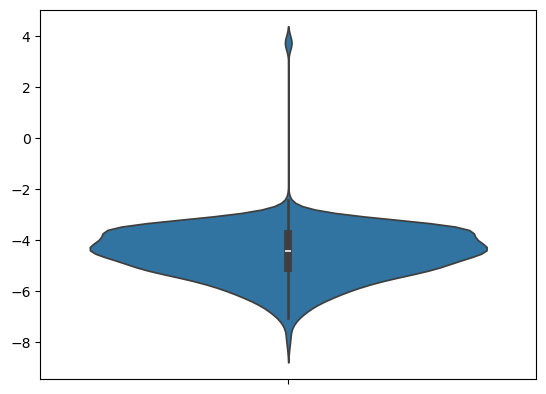

In [12]:
sns.violinplot(by_cre_thetas)

In [13]:
def minimax(QC):
    x=[]
    for level in QC.keys():
        if QC[level]["success"]:
            x.append(QC[level]["dat"])
    x=pd.concat(x)
    print(f"min {min(x['mu'])}, max {max(x['mu'])}")

print("cre")
minimax(primordial.by_cre_qc)

cre
min 0.0005816033840744891, max 2.7037965647833917


---
low r AATAGACTGGCGCGCGCGCCTGATGGCGCGCGCGCCTGATCAGGCTATACGTGTTGCGTTGTTGCAGCCCGTGGCGCGCGCGCCTGAACTGGCGCGCGCGCCTGATACCTCTGGGCTGTCACGCGGTGGCGCGCGCGCCTGAAGG
low r ACGCGCTTCGAGATAAGGTTACTTCCTCGTAAGGCCCCGCCCATACGCGTCTTCGAGGACGCGTCTTCTTATCTGTCTTCCCGCGCGCGGAGACGCGTCTTCTTCCTCGTATCGCCCCGCCCATGCGTTCTCTTGAGGACTTCCC
low r AGTCGCTGCGCGATATATCGTCCGCGAGATACGCTTCGCTCCGCCCGCGCTTCCTTCCGCGGAGTCGCGGGTCCTCGCCTCGCGCCTCTTATCGGTGCGCGGCGCTCTTTCGCGAGATATCGCCCCTTTTCGCGCGCTTCCTCGC
low r CCAAAGTCCGCTGGAAAGTACCCAGGGAGCTTGGGGGCTTTGGTCAAACTTTGCACTGCAGGCCTAAAGTCTCTACTGTAATCCTTTCACGTTTATGCCAAGGTCCCTTGTATACAAAACCAAAGTTCAAAGCTCCAGTACACAA
low r CCCCCCCATAACTTCCTATATCGGCGGGGGGGGAGGGGCGGGGCTTCCAGGAAGTGACTCATCGGGGCGGGGCGGGCCCCCCCCCCTATAGGCCCGCCCCCCCCCCCCTTCCCGGAAGCCCCGCCCCCAGAGGATGAGTCATCCG
low r CCCCCCCTATATCTCCCCCCCCGCTCTCACTCATGCGTCTTCCCGCGTTTTTCTTTTTCTATCCGCGTTTTCGCGTATCTTCCTTCCTATACGCTTTCTCATCCGCCCTCTCCTTCTCTCTTCTCCGCGCCCTCCCCCGTTCTCG
low r CCCCCCTTTCCAGGAAGTCGCGGAAGCGCTGAGTCACGATACGCCCCGCCCCCCCGCCCCCCCCCCCCCCCGCCGATG

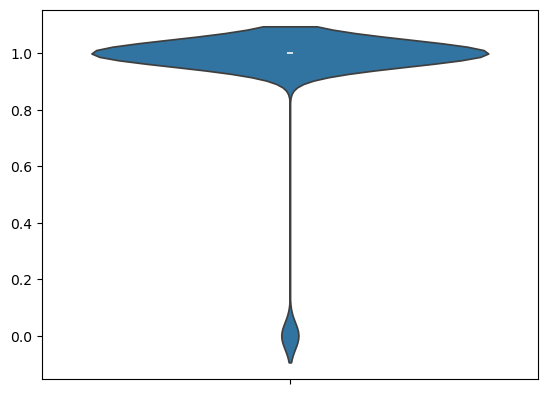

In [14]:


r=[]
for QC in [primordial.by_cre_qc]:
    print("---")
    
    for level in QC.keys():
        if QC[level]["success"]:
            if np.isnan(QC[level]["r_value"]):
                print(f"nan in {level}")
            else:
                if QC[level]["r_value"]<0.8:
                    print(f"low r {level}")
                r.append(QC[level]["r_value"])


sns.violinplot(r)

print(r)

In [23]:
zi=[]

for key in primordial.by_cre_parameters.zi:
    zi.append(primordial.by_cre_parameters.zi[key].result()["zi"])

In [26]:
np.mean(zi)

0.0098052067100394

<Axes: >

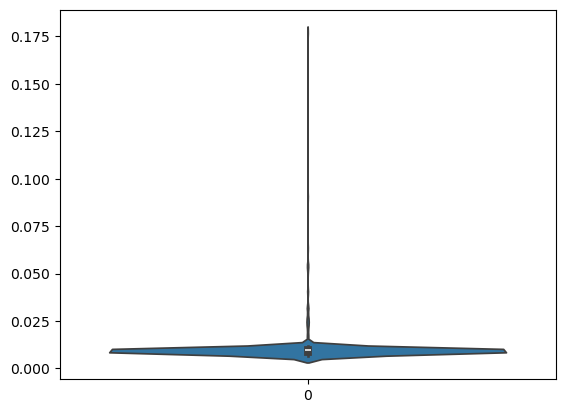

In [30]:
sns.violinplot(np.array(zi))

In [15]:
print("finished!")

finished!


In [ ]:
client.close()
cluster.close()